# EE 446 TinyML — Lab 3  
## Quantization of a DNN Using the UCI Human Activity Recognition Dataset

This is the **student version** of the lab notebook.

Complete all code cells marked with **TODO**.  
Use clear variable names and keep the overall notebook structure unchanged.


## 1. Environment Setup

Use the `Python (tinyml-arduino)` Jupyter kernel for this notebook.
All required packages are expected to be preinstalled in the course environment.


In [1]:
import sys
#!{sys.executable} -m pip install -q "tensorflow==2.15.1" "tensorflow-model-optimization==0.8.0" "scikit-learn==1.4.2" "pandas==2.2.2" "matplotlib==3.8.4"


## 2. Imports and Reproducibility


In [2]:
import os
import zipfile
import pathlib
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_model_optimization as tfmot

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("TF-MOT version:", tfmot.__version__)


2026-04-23 20:16:50.256292: I tensorflow/core/util/port.cc:111] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-23 20:16:50.332733: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-23 20:16:50.651047: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-23 20:16:50.651103: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-23 20:16:50.652616: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to regi

TensorFlow version: 2.14.1
TF-MOT version: 0.8.0


## 3. Download and Extract the UCI HAR Dataset

The original dataset contains:
- **561 numerical features** extracted from smartphone sensor signals
- **6 activity classes**
- predefined **training** and **test** splits

The code below downloads and extracts the dataset if it is not already present.


In [3]:
dataset_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip"
zip_path = "uci_har_dataset.zip"
extract_dir = "."

if not os.path.exists("UCI HAR Dataset"):
    !wget -q "{dataset_url}" -O "{zip_path}"
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(extract_dir)
    print("Dataset downloaded and extracted.")
else:
    print("Dataset directory already exists.")


Dataset directory already exists.


## 4. Load the Data


In [4]:
data_path = "/mnt/c/Users/bobby/Downloads/tinyml_env_setup_package/tinyml_env_setup_package/UCI HAR Dataset"
def load_har_data(root_dir="UCI HAR Dataset"):
    # TODO:
    # 1. Load X_train from train/X_train.txt
    # 2. Load y_train from train/y_train.txt
    # 3. Load X_test from test/X_test.txt
    # 4. Load y_test from test/y_test.txt
    # 5. Convert the labels to zero-based class indices by subtracting 1

    # <-- Enter your code here <--#
    X_train = np.loadtxt(os.path.join(root_dir, "train", "X_train.txt"))
    y_train = np.loadtxt(os.path.join(root_dir, "train", "y_train.txt")).astype(int) - 1

    X_test = np.loadtxt(os.path.join(root_dir, "test", "X_test.txt"))
    y_test = np.loadtxt(os.path.join(root_dir, "test", "y_test.txt")).astype(int) - 1

    return X_train, y_train, X_test, y_test
    #raise NotImplementedError("Complete the data-loading function.")

X_train, y_train, X_test, y_test = load_har_data()

class_names = [
    "WALKING",
    "WALKING_UPSTAIRS",
    "WALKING_DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING"
]

# TODO: define num_features and num_classes
# <-- Enter your code here <--#
num_features = X_train.shape[1]
num_classes = len(np.unique(y_train))

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("Number of input features:", num_features)
print("Number of classes:", num_classes)

X_train shape: (7352, 561)
X_test shape : (2947, 561)
Number of input features: 561
Number of classes: 6


## 5. Quick Inspection


In [5]:
# TODO:
# Create a small summary table showing the class index, class name, and number of training samples.

# <-- Enter your code here <--#

label_counts = pd.Series(y_train).value_counts().sort_index()
summary_df = pd.DataFrame({
    "Class Index": range(num_classes),
    "Class Name": class_names,
    "Training Samples": label_counts.values
})
summary_df

,Class Index,Class Name,Training Samples
0,0,WALKING,1226
1,1,WALKING_UPSTAIRS,1073
2,2,WALKING_DOWNSTAIRS,986
3,3,SITTING,1286
4,4,STANDING,1374
5,5,LAYING,1407


## 6. Train a Baseline DNN

We will use a compact dense neural network that is appropriate for a numerical-feature TinyML-style workflow.

### Architecture
- Input: 561 features
- Dense(256, ReLU)
- Dense(128, ReLU)
- Dense(64, ReLU)
- Dense(6, Softmax)


In [6]:
from tensorflow.keras import Model, Input
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

def build_baseline_model(input_dim, num_classes):
    # TODO:
    # Build and compile a DNN with the following architecture:
    # Input -> Dense(256, relu) -> Dense(128, relu) -> Dense(64, relu) -> Dense(num_classes, softmax)
    # Use Adam with learning rate 1e-3.
    # Use sparse_categorical_crossentropy as the loss.
    # Track accuracy as a metric.

    # <-- Enter your code here <--#
    model = tf.keras.Sequential([
        Input(shape=(input_dim,)),
        Dense(256, activation="relu"),
        Dense(128, activation="relu"),
        Dense(64, activation="relu"),
        Dense(num_classes, activation="softmax")
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model
    #raise NotImplementedError("Complete the baseline DNN.")

baseline_model = build_baseline_model(num_features, num_classes)
baseline_model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 256)               143872    
                                                                 
 dense_1 (Dense)             (None, 128)               32896     
                                                                 
 dense_2 (Dense)             (None, 64)                8256      
                                                                 
 dense_3 (Dense)             (None, 6)                 390       
                                                                 
Total params: 185414 (724.27 KB)
Trainable params: 185414 (724.27 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


### Train the Baseline Model


In [7]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        restore_best_weights=True
    )
]

# TODO:
# Train the baseline model using:
# - validation_split=0.2
# - epochs=40
# - batch_size=64
# - callbacks=callbacks

# <-- Enter your code here <--#
history = baseline_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=40,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/40
92/92 [==============================] - 1s 6ms/step - loss: 0.4880 - accuracy: 0.8075 - val_loss: 0.2016 - val_accuracy: 0.9245
Epoch 2/40
92/92 [==============================] - 0s 4ms/step - loss: 0.1640 - accuracy: 0.9367 - val_loss: 0.1402 - val_accuracy: 0.9381
Epoch 3/40
92/92 [==============================] - 0s 4ms/step - loss: 0.1165 - accuracy: 0.9561 - val_loss: 0.2180 - val_accuracy: 0.9259
Epoch 4/40
92/92 [==============================] - 0s 4ms/step - loss: 0.0886 - accuracy: 0.9641 - val_loss: 0.1500 - val_accuracy: 0.9402
Epoch 5/40
92/92 [==============================] - 0s 4ms/step - loss: 0.0885 - accuracy: 0.9645 - val_loss: 0.2037 - val_accuracy: 0.9218
Epoch 6/40
92/92 [==============================] - 0s 4ms/step - loss: 0.0748 - accuracy: 0.9711 - val_loss: 0.2056 - val_accuracy: 0.9313
Epoch 7/40
92/92 [==============================] - 0s 5ms/step - loss: 0.0765 - accuracy: 0.9716 - val_loss: 0.1482 - val_accuracy: 0.9443
Epoch 8/40
92/92 [==

### Training Curves


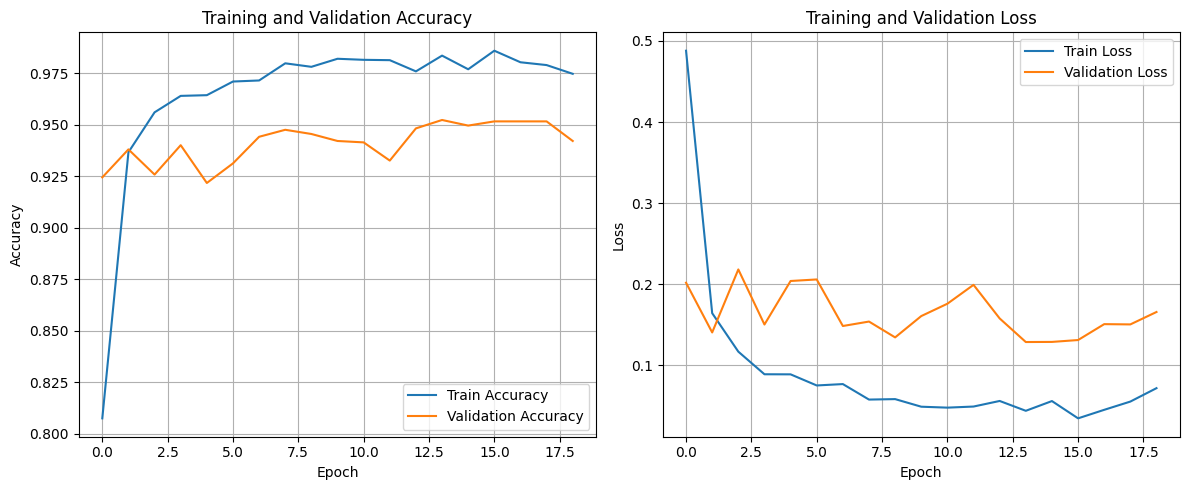

In [8]:
# TODO:
# Plot the training and validation accuracy.
# Plot the training and validation loss.

# <-- Enter your code here <--#
plt.figure(figsize=(12, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


## 7. Evaluate the Baseline Keras Model


Baseline Test Accuracy: 0.9352

                    precision    recall  f1-score   support

           WALKING     0.9524    0.9677    0.9600       496
  WALKING_UPSTAIRS     0.9483    0.9342    0.9412       471
WALKING_DOWNSTAIRS     0.9360    0.9405    0.9382       420
           SITTING     0.8762    0.9226    0.8988       491
          STANDING     0.8998    0.8778    0.8887       532
            LAYING     1.0000    0.9702    0.9849       537

          accuracy                         0.9352      2947
         macro avg     0.9354    0.9355    0.9353      2947
      weighted avg     0.9359    0.9352    0.9354      2947



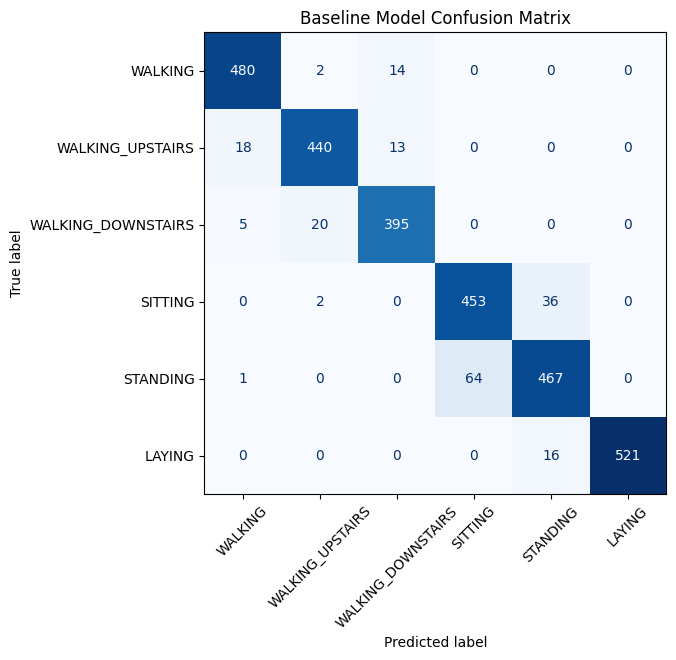

In [9]:
# TODO:
# 1. Obtain predicted probabilities on X_test
# 2. Convert them to class predictions using argmax
# 3. Compute test accuracy
# 4. Print the classification report
# 5. Plot the confusion matrix

# <-- Enter your code here <--#
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# 1. Obtain predicted probabilities on X_test
baseline_probs = baseline_model.predict(X_test, verbose=0)

# 2. Convert them to class predictions using argmax
baseline_preds = np.argmax(baseline_probs, axis=1)

# 3. Compute test accuracy
baseline_test_acc = accuracy_score(y_test, baseline_preds)
print(f"Baseline Test Accuracy: {baseline_test_acc:.4f}\n")

# 4. Print the classification report
print(classification_report(y_test, baseline_preds, target_names=class_names, digits=4))

# 5. Plot the confusion matrix
cm = confusion_matrix(y_test, baseline_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
plt.title("Baseline Model Confusion Matrix")
plt.show()

## 8. TensorFlow Lite Utilities

The following helper functions are used to:
- convert Keras models to TensorFlow Lite,
- evaluate TensorFlow Lite models on the test set, and
- measure model file size.


In [10]:
def save_binary_model(model_content, filename):
    with open(filename, "wb") as f:
        f.write(model_content)
    return os.path.getsize(filename) / 1024.0  # KB

def representative_dataset_gen():
    # TODO:
    # Yield 300 representative samples from X_train as float32 tensors.
    # Each yielded item should be in the form: [sample]

    # <-- Enter your code here <--#
    for i in range(300):
        yield [X_train[i:i+1].astype(np.float32)]
    #raise NotImplementedError("Complete the representative dataset generator.")

def evaluate_tflite_model(tflite_model, X, y_true):
    interpreter = tf.lite.Interpreter(model_content=tflite_model)
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]

    input_scale, input_zero_point = input_details["quantization"]
    output_scale, output_zero_point = output_details["quantization"]

    y_pred = []

    for i in range(len(X)):
        x = X[i:i+1].astype(np.float32)

        # TODO:
        # Quantize the input only when the input dtype is int8 or uint8.
        # Otherwise keep the input in the required floating-point dtype.

        # <-- Enter your code here <--#
        if input_details["dtype"] == np.int8:
            x = np.round(x / input_scale+input_zero_point).astype(np.int8)
        elif input_details["dtype"] == np.uint8:
            x = np.round(x / input_scale+input_zero_point).astype(np.uint8)
        else:
            x = x.astype(input_details["dtype"])
            
        interpreter.set_tensor(input_details["index"], x)
        interpreter.invoke()

        output = interpreter.get_tensor(output_details["index"])

        # TODO:
        # If the output is quantized, dequantize it back to float32.

        # <-- Enter your code here <--#

        if output_details["dtype"] in (np.int8, np.uint8):
            output = (output.astype(np.float32) - output_zero_point) * output_scale
            
        y_pred.append(np.argmax(output, axis=1)[0])

    y_pred = np.array(y_pred)
    acc = accuracy_score(y_true, y_pred)
    return acc, y_pred

def convert_to_tflite_fp32(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    # TODO: return the converted FP32 TensorFlow Lite model
    # <-- Enter your code here <--#
    return converter.convert()

def convert_to_tflite_dynamic_range(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    # TODO:
    # Apply default optimization and return the converted model.

    # <-- Enter your code here <--#
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    return converter.convert()

def convert_to_tflite_float16(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    # TODO:
    # Apply default optimization
    # Set supported_types to [tf.float16]
    # Return the converted model

    # <-- Enter your code here <--#
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.target_spec.supported_types = [tf.float16]
    return converter.convert()

def convert_to_tflite_int8(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    # TODO:
    # Apply default optimization
    # Attach representative_dataset_gen
    # Restrict to TFLITE_BUILTINS_INT8
    # Set inference_input_type and inference_output_type to tf.int8
    # Return the converted model

    # <-- Enter your code here <--#
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.representative_dataset = representative_dataset_gen
    converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
    converter.inference_input_type = tf.int8
    converter.interence_output_type = tf.int8
    return converter.convert()

## 9. Post-Training Quantization (PTQ)


In [11]:
# TODO:
# Convert the baseline model into:
# - FP32 TFLite
# - dynamic range TFLite
# - float16 TFLite
# - int8 TFLite

# Save each model to disk and record its size in KB.
# Evaluate each TFLite model on the test set.

# <-- Enter your code here <--#
fp32_tflite_model = convert_to_tflite_fp32(baseline_model)
drq_tflite_model = convert_to_tflite_dynamic_range(baseline_model)
float16_tflite_model = convert_to_tflite_float16(baseline_model)
int8_tflite_model = convert_to_tflite_int8(baseline_model)

# Save each model to disk and record its size in KB.
fp32_size_kb = save_binary_model(fp32_tflite_model, "baseline_fp32.tflite")
drq_size_kb = save_binary_model(drq_tflite_model, "baseline_dynamic_range.tflite")
float16_size_kb = save_binary_model(float16_tflite_model, "baseline_float16.tflite")
int8_size_kb = save_binary_model(int8_tflite_model, "baseline_int8.tflite")

# Evaluate each TFLite model on the test set.
fp32_acc, fp32_preds = evaluate_tflite_model(fp32_tflite_model, X_test, y_test)
drq_acc, drq_preds = evaluate_tflite_model(drq_tflite_model, X_test, y_test)
float16_acc, float16_preds = evaluate_tflite_model(float16_tflite_model, X_test, y_test)
int8_acc, int8_preds = evaluate_tflite_model(int8_tflite_model, X_test, y_test)

INFO:tensorflow:Assets written to: /tmp/tmp3ibcuz8u/assets


INFO:tensorflow:Assets written to: /tmp/tmp3ibcuz8u/assets
2026-04-23 20:17:08.013555: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-23 20:17:08.013703: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-23 20:17:08.014193: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmp3ibcuz8u
2026-04-23 20:17:08.015178: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-23 20:17:08.015192: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmp3ibcuz8u
2026-04-23 20:17:08.019281: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:382] MLIR V1 optimization pass is not enabled
2026-04-23 20:17:08.020141: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-23 20:17:08.062469: I tensorflow/cc/saved_model/loader.cc:217] Running initializatio

INFO:tensorflow:Assets written to: /tmp/tmps7mynmrz/assets


INFO:tensorflow:Assets written to: /tmp/tmps7mynmrz/assets
2026-04-23 20:17:08.556141: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-23 20:17:08.556257: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-23 20:17:08.556543: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmps7mynmrz
2026-04-23 20:17:08.557323: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-23 20:17:08.557339: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmps7mynmrz
2026-04-23 20:17:08.558838: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-23 20:17:08.589456: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmps7mynmrz
2026-04-23 20:17:08.596712: I tensorflow/cc/saved_model/loader.cc:316] SavedModel

INFO:tensorflow:Assets written to: /tmp/tmpr7416ko3/assets


INFO:tensorflow:Assets written to: /tmp/tmpr7416ko3/assets
2026-04-23 20:17:09.044307: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-23 20:17:09.044371: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-23 20:17:09.044506: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpr7416ko3
2026-04-23 20:17:09.045258: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-23 20:17:09.045280: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpr7416ko3
2026-04-23 20:17:09.048540: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-23 20:17:09.082241: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmpr7416ko3
2026-04-23 20:17:09.089690: I tensorflow/cc/saved_model/loader.cc:316] SavedModel

INFO:tensorflow:Assets written to: /tmp/tmpnsiapm3e/assets


INFO:tensorflow:Assets written to: /tmp/tmpnsiapm3e/assets
/home/btaing14/ai/projects/tinyml-arduino/lib/python3.11/site-packages/tensorflow/lite/python/convert.py:947: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
2026-04-23 20:17:09.858774: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-23 20:17:09.858886: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-23 20:17:09.859160: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpnsiapm3e
2026-04-23 20:17:09.860271: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-23 20:17:09.860293: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpnsiapm3e
2026-04-23 20:17:09.863194: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.


## 10. PTQ Comparison: Accuracy and Model Size


In [12]:
# TODO:
# Create a comparison DataFrame containing:
# Model Family, Format, Test Accuracy, Model Size (KB)

# <-- Enter your code here <--#
ptq_results_df = pd.DataFrame([
    {
        "Model Family": "Baseline",
        "Format": "FP32 TFLite",
        "Test Accuracy": fp32_acc,
        "Model Size (KB)": fp32_size_kb
    },
    {
        "Model Family": "Baseline",
        "Format": "Dynamic Range TFLite",
        "Test Accuracy": drq_acc,
        "Model Size (KB)": drq_size_kb
    },
    {
        "Model Family": "Baseline",
        "Format": "Float16 TFLite",
        "Test Accuracy": float16_acc,
        "Model Size (KB)": float16_size_kb
    },
    {
        "Model Family": "Baseline",
        "Format": "INT8 TFLite",
        "Test Accuracy": int8_acc,
        "Model Size (KB)": int8_size_kb
    }
])

ptq_results_df

,Model Family,Format,Test Accuracy,Model Size (KB)
0,Baseline,FP32 TFLite,0.935188,726.718750
1,Baseline,Dynamic Range TFLite,0.935867,186.109375
2,Baseline,Float16 TFLite,0.935188,365.710938
3,Baseline,INT8 TFLite,0.935528,185.507812


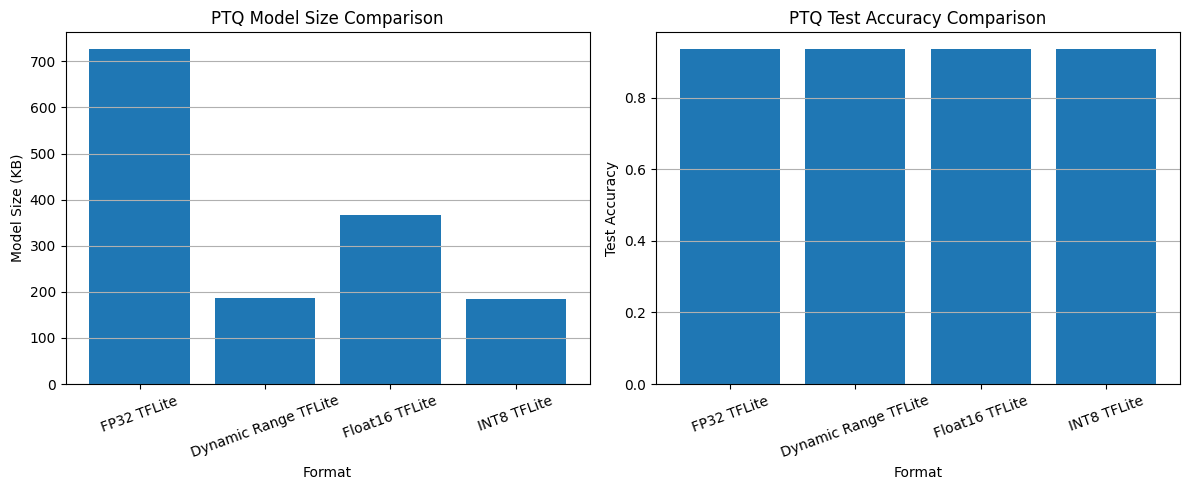

In [13]:
# TODO:
# Create one bar plot for model size and another for test accuracy.

# <-- Enter your code here <--#
plt.figure(figsize=(12, 5))

# Model size
plt.subplot(1, 2, 1)
plt.bar(ptq_results_df["Format"], ptq_results_df["Model Size (KB)"])
plt.title("PTQ Model Size Comparison")
plt.xlabel("Format")
plt.ylabel("Model Size (KB)")
plt.xticks(rotation=20)
plt.grid(True, axis="y")

# Accuracy
plt.subplot(1, 2, 2)
plt.bar(ptq_results_df["Format"], ptq_results_df["Test Accuracy"])
plt.title("PTQ Test Accuracy Comparison")
plt.xlabel("Format")
plt.ylabel("Test Accuracy")
plt.xticks(rotation=20)
plt.grid(True, axis="y")

plt.tight_layout()
plt.show()

### Confusion Matrix for the PTQ Int8 Model


PTQ INT8 Classification Report:

                    precision    recall  f1-score   support

           WALKING     0.9524    0.9677    0.9600       496
  WALKING_UPSTAIRS     0.9484    0.9363    0.9423       471
WALKING_DOWNSTAIRS     0.9382    0.9405    0.9394       420
           SITTING     0.8794    0.9206    0.8995       491
          STANDING     0.8967    0.8816    0.8891       532
            LAYING     1.0000    0.9683    0.9839       537

          accuracy                         0.9355      2947
         macro avg     0.9359    0.9358    0.9357      2947
      weighted avg     0.9362    0.9355    0.9357      2947



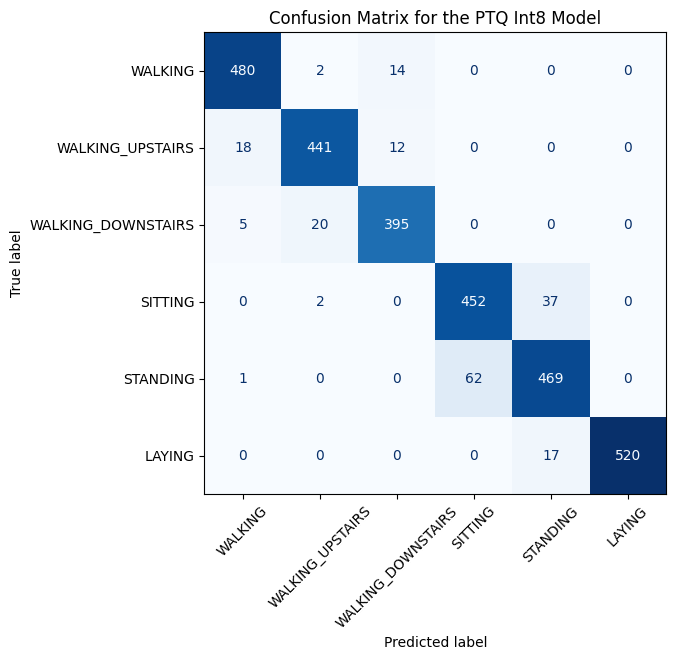

In [14]:
# TODO:
# Plot the confusion matrix for the PTQ int8 model.
# Print the classification report for the PTQ int8 model.

# <-- Enter your code here <--#
print("PTQ INT8 Classification Report:\n")
print(classification_report(y_test, int8_preds, target_names=class_names, digits=4))

cm_int8 = confusion_matrix(y_test, int8_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_int8, display_labels=class_names)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
plt.title("Confusion Matrix for the PTQ Int8 Model")
plt.show()


## 11. Quantization-Aware Training (QAT)

QAT simulates quantization effects during training so that the final model is usually more robust after conversion to int8.


In [15]:
# TODO:
# Create a QAT model from the trained baseline model using TF-MOT.
# Compile it with Adam(1e-4), sparse_categorical_crossentropy, and accuracy.

# <-- Enter your code here <--#
import tensorflow_model_optimization as tfmot

qat_model = tfmot.quantization.keras.quantize_model(baseline_model)

qat_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

### Fine-Tune the QAT Model


In [16]:
# TODO:
# Fine-tune the QAT model for 8 epochs using validation_split=0.2 and batch_size=64.

# <-- Enter your code here <--#
qat_history = qat_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=8,
    batch_size=64,
    verbose=1
)


Epoch 1/8
92/92 [==============================] - 1s 7ms/step - loss: 0.0334 - accuracy: 0.9891 - val_loss: 0.1298 - val_accuracy: 0.9517
Epoch 2/8
92/92 [==============================] - 1s 6ms/step - loss: 0.0296 - accuracy: 0.9905 - val_loss: 0.1384 - val_accuracy: 0.9490
Epoch 3/8
92/92 [==============================] - 0s 5ms/step - loss: 0.0293 - accuracy: 0.9903 - val_loss: 0.1302 - val_accuracy: 0.9524
Epoch 4/8
92/92 [==============================] - 0s 5ms/step - loss: 0.0260 - accuracy: 0.9903 - val_loss: 0.1329 - val_accuracy: 0.9517
Epoch 5/8
92/92 [==============================] - 0s 5ms/step - loss: 0.0249 - accuracy: 0.9915 - val_loss: 0.1640 - val_accuracy: 0.9463
Epoch 6/8
92/92 [==============================] - 0s 5ms/step - loss: 0.0267 - accuracy: 0.9891 - val_loss: 0.1567 - val_accuracy: 0.9490
Epoch 7/8
92/92 [==============================] - 0s 5ms/step - loss: 0.0249 - accuracy: 0.9913 - val_loss: 0.1413 - val_accuracy: 0.9517
Epoch 8/8
92/92 [==========

### Evaluate the QAT Keras Model


In [17]:
# TODO:
# Evaluate the QAT Keras model on X_test.
# Print the test accuracy and classification report.

# <-- Enter your code here <--#
qat_probs = qat_model.predict(X_test, verbose=0)
qat_preds = np.argmax(qat_probs, axis=1)

qat_test_acc = accuracy_score(y_test, qat_preds)
print(f"QAT Keras Test Accuracy: {qat_test_acc:.4f}\n")

print(classification_report(y_test, qat_preds, target_names=class_names, digits=4))

QAT Keras Test Accuracy: 0.9345

                    precision    recall  f1-score   support

           WALKING     0.9186    0.9778    0.9473       496
  WALKING_UPSTAIRS     0.9446    0.9045    0.9241       471
WALKING_DOWNSTAIRS     0.9562    0.9357    0.9458       420
           SITTING     0.9615    0.8656    0.9110       491
          STANDING     0.8512    0.9680    0.9059       532
            LAYING     1.0000    0.9497    0.9742       537

          accuracy                         0.9345      2947
         macro avg     0.9387    0.9336    0.9347      2947
      weighted avg     0.9379    0.9345    0.9348      2947



### Convert the QAT Model to Int8 TensorFlow Lite


In [18]:
# TODO:
# Convert the QAT model to int8 TensorFlow Lite.
# Save the model, compute its size, and evaluate it on the test set.

# <-- Enter your code here <--#
qat_int8_tflite_model = convert_to_tflite_int8(qat_model)

qat_int8_size_kb = save_binary_model(qat_int8_tflite_model, "qat_int8.tflite")

qat_int8_acc, qat_int8_preds = evaluate_tflite_model(
    qat_int8_tflite_model,
    X_test,
    y_test
)

INFO:tensorflow:Assets written to: /tmp/tmpxgdj1ial/assets


INFO:tensorflow:Assets written to: /tmp/tmpxgdj1ial/assets
/home/btaing14/ai/projects/tinyml-arduino/lib/python3.11/site-packages/tensorflow/lite/python/convert.py:947: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
2026-04-23 20:17:17.944455: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-23 20:17:17.944519: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-23 20:17:17.944682: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpxgdj1ial
2026-04-23 20:17:17.947077: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-23 20:17:17.947115: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpxgdj1ial
2026-04-23 20:17:17.957118: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.


## 12. PTQ Int8 vs QAT Int8


In [19]:
# TODO:
# Create a DataFrame comparing PTQ int8 and QAT int8:
# Model, Test Accuracy, Model Size (KB)

# <-- Enter your code here <--#
int8_comparison_df = pd.DataFrame([
    {
        "Model": "PTQ INT8",
        "Test Accuracy": int8_acc,
        "Model Size (KB)": int8_size_kb
    },
    {
        "Model": "QAT INT8",
        "Test Accuracy": qat_int8_acc,
        "Model Size (KB)": qat_int8_size_kb
    }
])

int8_comparison_df

,Model,Test Accuracy,Model Size (KB)
0,PTQ INT8,0.935528,185.507812
1,QAT INT8,0.934510,185.875000


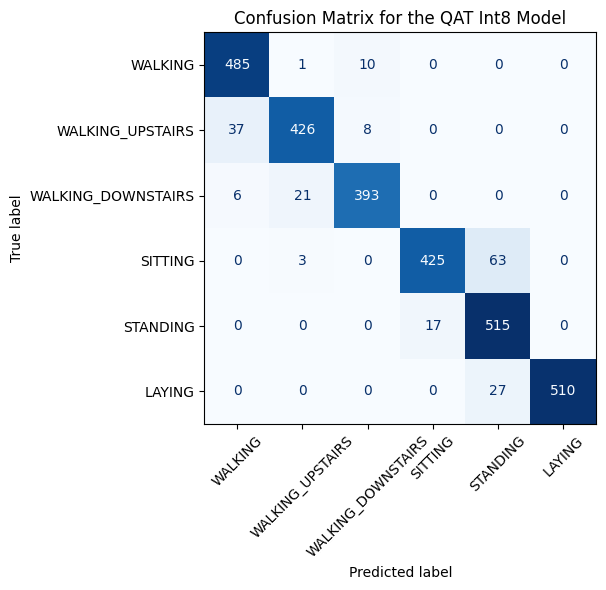

In [20]:
# TODO:
# Plot the confusion matrix for the QAT int8 model.

# <-- Enter your code here <--#
cm_qat_int8 = confusion_matrix(y_test, qat_int8_preds)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_qat_int8,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)

plt.title("Confusion Matrix for the QAT Int8 Model")
plt.tight_layout()
plt.show()

In [21]:
# Final Comparison Table

# TODO:
# Create a comparison DataFrame containing:
# Model Family, Format, Test Accuracy, Model Size (KB)

# <-- Enter your code here <--#
ptq_results_df = pd.DataFrame([
    {
        "Model": "FP32 TFLite",
        "Test Accuracy": fp32_acc,
        "Model Size (KB)": fp32_size_kb
    },
    {
        "Model": "Dynamic Range TFLite",
        "Test Accuracy": drq_acc,
        "Model Size (KB)": drq_size_kb
    },
    {
        "Model": "Float16 TFLite",
        "Test Accuracy": float16_acc,
        "Model Size (KB)": float16_size_kb
    },
    {
        "Model": "INT8 TFLite",
        "Test Accuracy": int8_acc,
        "Model Size (KB)": int8_size_kb
    },
    {
        "Model": "PTQ INT8",
        "Test Accuracy": int8_acc,
        "Model Size (KB)": int8_size_kb
    },
    {
        "Model": "QAT INT8",
        "Test Accuracy": qat_int8_acc,
        "Model Size (KB)": qat_int8_size_kb
    }
])

ptq_results_df

,Model,Test Accuracy,Model Size (KB)
0,FP32 TFLite,0.935188,726.718750
1,Dynamic Range TFLite,0.935867,186.109375
2,Float16 TFLite,0.935188,365.710938
3,INT8 TFLite,0.935528,185.507812
4,PTQ INT8,0.935528,185.507812
5,QAT INT8,0.934510,185.875000


## 13. Summary Questions

Write short answers to the following:
1. Which quantization method gave the smallest model size?
2. Which quantization method gave the best accuracy among the TensorFlow Lite models?
3. Did QAT improve the final int8 model compared with PTQ int8?
4. Why is this dataset a good fit for a DNN-based TinyML workflow?
5. If you were deploying this model on a resource-constrained device, which version would you choose and why?


1. PTQ INT8 model have the smallest model size (185.51 KB)
2. PTQ INT8 model at accuracy about 93.55%
3. No, it achieved about 93.45% accuracy, 
   which is slightly lower than PTQ INT8
4. The UCI HAR dataset uses fixed-length numerical sensor features, 
   suited for a compact feedforward neural network with low memory and fast inference
5. PTQ INT8 model because it had the best accuracy while also 
   having the smallest model size

## 14. Submission Requirements

Submit the following:
- your completed notebook,
- the generated `.tflite` files,
- screenshots or output cells showing the final comparison table,
- confusion matrices for the baseline model and the final int8 model you want to highlight,
- and short written observations answering the summary questions.

Make sure your notebook runs from top to bottom without errors.
